# Customer Churn Prediction & Risk Segmentation Dashboard

## Project Overview

In this project, I developed a machine learning-based customer churn prediction and risk segmentation system using a telecom customer dataset. The main objective of this project is to identify customers who are likely to leave the service and categorize them into different risk tiers based on churn probability. 

Through this analysis, I aimed to understand important customer behavior patterns, evaluate multiple machine learning models, and generate business insights that can help improve customer retention strategies.

### The project includes:

- Exploratory Data Analysis (EDA)
- Data preprocessing and feature engineering
- Model training and performance evaluation
- Customer risk segmentation
- Feature importance analysis
- Business insights and recommendations
- Data visualization using Matplotlib, Seaborn, and Plotly

## TASK 1 — Data Loading & Exploratory Analysis

In this task, I loaded the telecom customer churn dataset and performed Exploratory Data Analysis (EDA) to better understand customer behavior patterns, dataset structure, missing values, and relationships between important features. This analysis helped in identifying useful trends and preparing the dataset for machine learning model development.

In [1]:
# Data manipulation libraries
import pandas as pd
import numpy as np

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Creating charts folder automatically
import os
os.makedirs('charts', exist_ok=True)


# Machine learning libraries
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading telecom churn dataset
customer_df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display dataset shape
print(f"Dataset Shape: {customer_df.shape}")

# Display first 10 rows
customer_df.head(10)

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

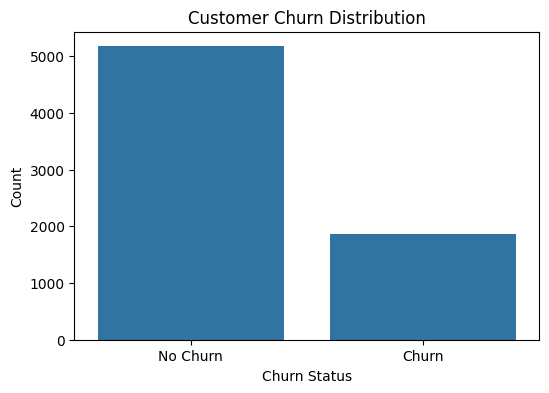

In [3]:
# Display dataset information
customer_df.info()

# Check missing/null values in all columns
print(customer_df.isnull().sum())

# Display summary statistics for numerical columns
print("\nSummary Statistics:")
print(customer_df.describe())

# Display median values of numerical features
print("\nMedian Values:")
print(customer_df.median(numeric_only=True))

# Plot customer churn distribution
plt.figure(figsize=(6,4))

# Creating churn count plot
ax = sns.countplot(
    x='Churn',
    data=customer_df
)

# Renaming x-axis labels for better readability
ax.set_xticklabels(['No Churn', 'Churn'])

# Adding chart title and axis labels
plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Count')

# Displaying the chart
plt.show()

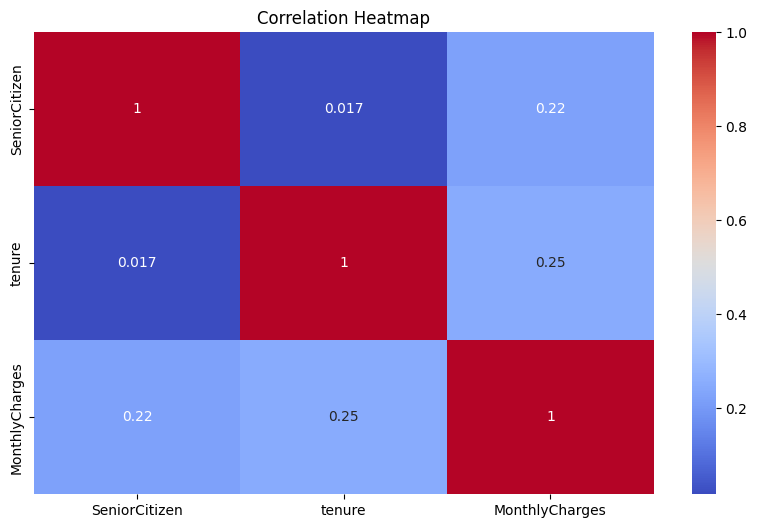

In [4]:
# Correlation Heatmap
plt.figure(figsize=(10,6))

numeric_df = customer_df.select_dtypes(
    include=['int64', 'float64']
)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

## TASK 2 — Data Preprocessing & Feature Engineering

In this task, I cleaned and prepared the dataset for machine learning by handling missing values, encoding categorical variables, and performing feature engineering. I also created new features to better capture customer behavior patterns and improve the overall prediction performance of the models.

In [5]:
# Convert TotalCharges to numeric format/
customer_df['TotalCharges'] = pd.to_numeric(
customer_df['TotalCharges'],
errors='coerce'
)
customer_df = customer_df.dropna()


In [6]:
# Create ChargesPerMonth feature
customer_df['ChargesPerMonth'] = (
    customer_df['TotalCharges'] /
    (customer_df['tenure'] + 1)
)
# Create SeniorWithNoSupport feature
customer_df['SeniorWithNoSupport'] = (
    (customer_df['SeniorCitizen'] == 1) &
    (customer_df['TechSupport'] == 'No')
).astype(int)
# Create customer tenure groups
customer_df['TenureGroup'] = pd.cut(
    customer_df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-1 Year', '1-2 Years', '2-4 Years', '4-6 Years']
)

### Encoding Technique Used

One-Hot Encoding was used because most categorical variables in the dataset are nominal and do not have ordinal relationships. This method avoids introducing false ranking between categories and improves model interpretability.

In [7]:
# Remove customerID column
customer_df.drop('customerID', axis=1, inplace=True)

# Apply One-Hot Encoding
customer_df = pd.get_dummies(customer_df, drop_first=True)

In [8]:
# Separate features and target variable
X = customer_df.drop('Churn_Yes', axis=1)
y = customer_df['Churn_Yes']

# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
# Apply feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## TASK 3 — Model Training & Comparison

In this task, I trained multiple machine learning classification models to predict customer churn and compared their performance using different evaluation metrics such as Accuracy, Precision, Recall, F1-Score, and ROC-AUC. This comparison helped in identifying the most effective and reliable model for churn prediction.

In [10]:
# Function to evaluate model performance
# Returns important classification metrics
def evaluate_model(model_name, y_test, y_pred, y_prob):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

In [11]:
# Function to plot confusion matrix
def plot_confusion(model_name, y_test, y_pred, ax):

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Churn', 'Churn']
    )

    disp.plot(ax=ax, cmap='Purples', colorbar=False)
    ax.set_title(model_name)

In [12]:
# Function to plot ROC curve
def plot_roc_curve(model_name, y_test, y_prob):

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{model_name} (AUC = {roc_auc:.3f})'
    )

In [13]:
# Initialize machine learning models
models = {

    'Logistic Regression': LogisticRegression(max_iter=1000),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    )
}

In [14]:
results = []
trained_models = {}

for name, model in models.items():

    # Use scaled data only for Logistic Regression
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    # Store trained model
    trained_models[name] = model

    # Store evaluation metrics
    result = evaluate_model(name, y_test, y_pred, y_prob)
    results.append(result)

    print(f'{name} trained successfully.')

Logistic Regression trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


In [15]:
# Store results and trained models
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='ROC-AUC',
    ascending=False
)

results_df.round(3)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.795,0.636,0.532,0.579,0.837
2,Gradient Boosting,0.785,0.610,0.535,0.570,0.834
1,Random Forest,0.792,0.639,0.497,0.559,0.833


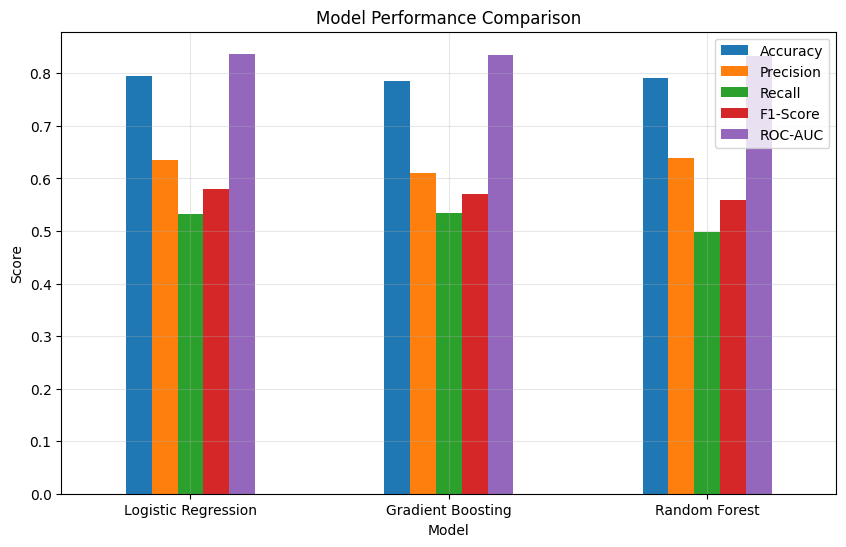

In [16]:
# Set 'Model' column as index for better visualization
results_df.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
].plot(
    kind='bar',       
    figsize=(10,6)       
)

# Adding title
plt.title('Model Performance Comparison')

# Labelling the y-axis
plt.ylabel('Score')

# x-axis labels
plt.xticks(rotation=0)

plt.grid(alpha=0.3)
# Display the plot
plt.show()

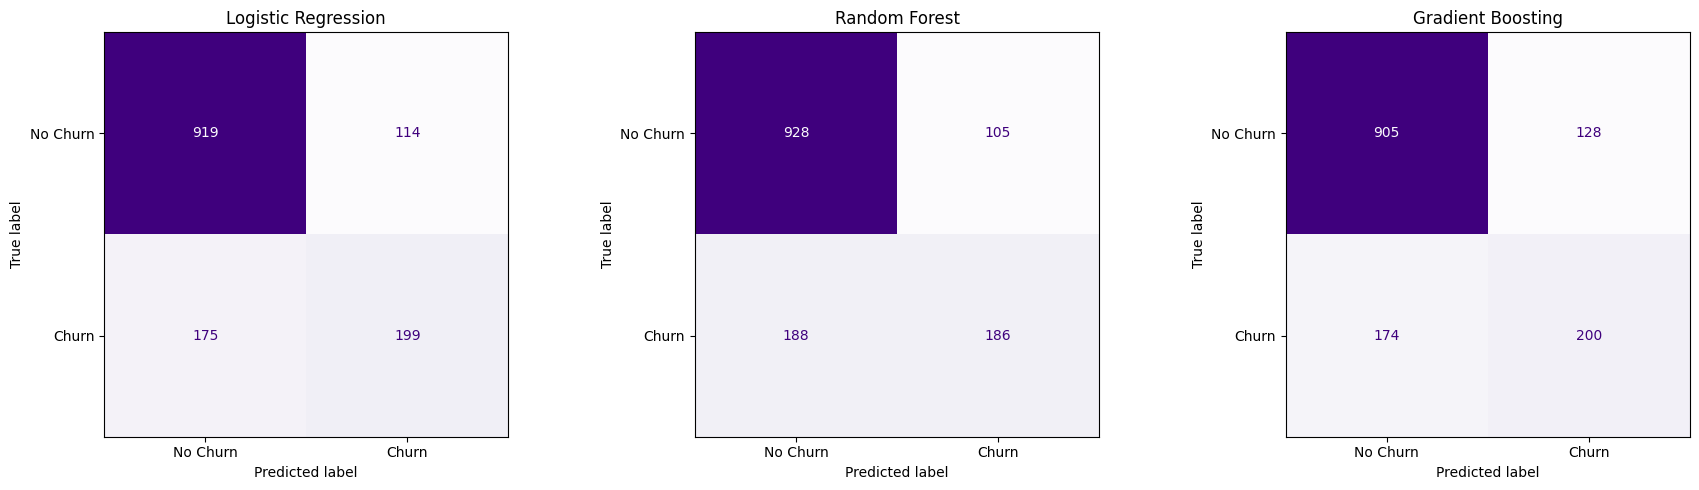

In [17]:
# Creating subplots to display confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, trained_models.items()):

    if name == 'Logistic Regression':
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    plot_confusion(name, y_test, y_pred, ax)

plt.tight_layout()

plt.show()

### Classification Report for All Models

The classification report provides a detailed breakdown of Precision, Recall, F1-Score, and Support for churn and non-churn predictions across all trained models.

In [18]:
# Displaying classification reports for all models

for name, model in trained_models.items():

    # Logistic Regression uses scaled data
    if name == 'Logistic Regression':
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    print("\n")
    print(f"{'='*60}")
    print(f"Classification Report - {name}")
    print(f"{'='*60}")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=['No Churn', 'Churn']
        )
    )



Classification Report - Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1033
       Churn       0.64      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.79      0.79      1407



Classification Report - Random Forest
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1033
       Churn       0.64      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



Classification Report - Gradient Boosting
              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1033
       Churn       0.61      0.53      0.57       374

    accuracy                           0.79      140

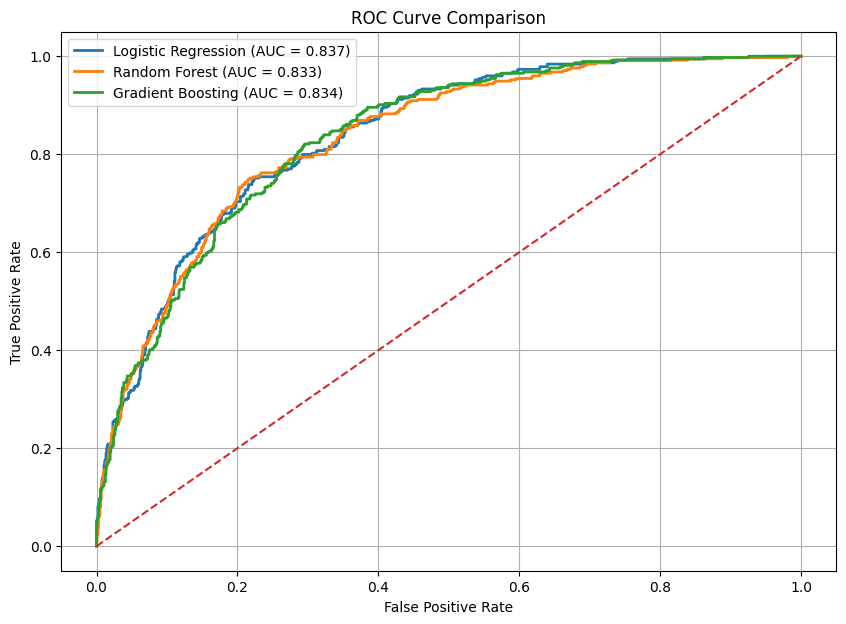

In [19]:
# Creating figure for ROC curve comparison
plt.figure(figsize=(10, 7))

for name, model in trained_models.items():

    if name == 'Logistic Regression':
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.predict_proba(X_test)[:, 1]

    plot_roc_curve(name, y_test, y_prob)

plt.plot([0, 1], [0, 1], linestyle='--')

# Adding labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')


plt.legend()
plt.grid(True)

# Saving the figure
plt.savefig('model_comparison.png', dpi=300)

plt.show()

In [20]:
# Defining parameter values for hyperparameter tuning
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}

# Applying Randomized Search CV to find best Logistic Regression parameters
random_search = RandomizedSearchCV(
    estimator=LogisticRegression(max_iter=2000),
    param_distributions=param_grid,
    n_iter=10,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Training the model with different parameter combinations
random_search.fit(
    X_train_scaled,
    y_train
)

best_model = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest ROC-AUC Score:")
print(random_search.best_score_)

Best Parameters:
{'solver': 'liblinear', 'penalty': 'l2', 'C': 100}

Best ROC-AUC Score:
0.8488849028642692


## TASK 4 — Customer Risk Segmentation

In this task, I used predicted churn probabilities to segment customers into different risk categories such as High Risk, Medium Risk, and Low Risk. This analysis helped in identifying customers who are more likely to leave the service and understanding the behavior patterns associated with each risk group.

In [21]:
# Predicting churn probabilities using the best model
churn_probabilities = best_model.predict_proba(X_test_scaled)[:, 1]

# Creating a new dataframe for risk analysis
risk_df = X_test.copy()

# Adding actual churn values
risk_df['ActualChurn'] = y_test.values

# Adding predicted churn probabilities
risk_df['ChurnProbability'] = churn_probabilities

In [22]:
# Function to categorize customers based on churn probability
def assign_risk(probability):

    if probability >= 0.70:
        return 'High Risk'

    elif probability >= 0.40:
        return 'Medium Risk'

    else:
        return 'Low Risk'

In [23]:
# Assigning risk level to each customer
risk_df['RiskTier'] = risk_df['ChurnProbability'].apply(assign_risk)

# Checking number of customers in each risk category
risk_df['RiskTier'].value_counts()

RiskTier
Low Risk       976
Medium Risk    306
High Risk      125
Name: count, dtype: int64

In [24]:
# Creating summary statistics for each risk tier
risk_summary = risk_df.groupby('RiskTier').agg({
    'MonthlyCharges': 'mean',
    'tenure': 'mean',
    'ChurnProbability': 'mean'
}).round(2)

# Displaying summarized risk analysis
risk_summary

,MonthlyCharges,tenure,ChurnProbability
RiskTier,,,
High Risk,80.52,3.70,0.78
Low Risk,58.23,40.11,0.13
Medium Risk,75.63,17.06,0.54


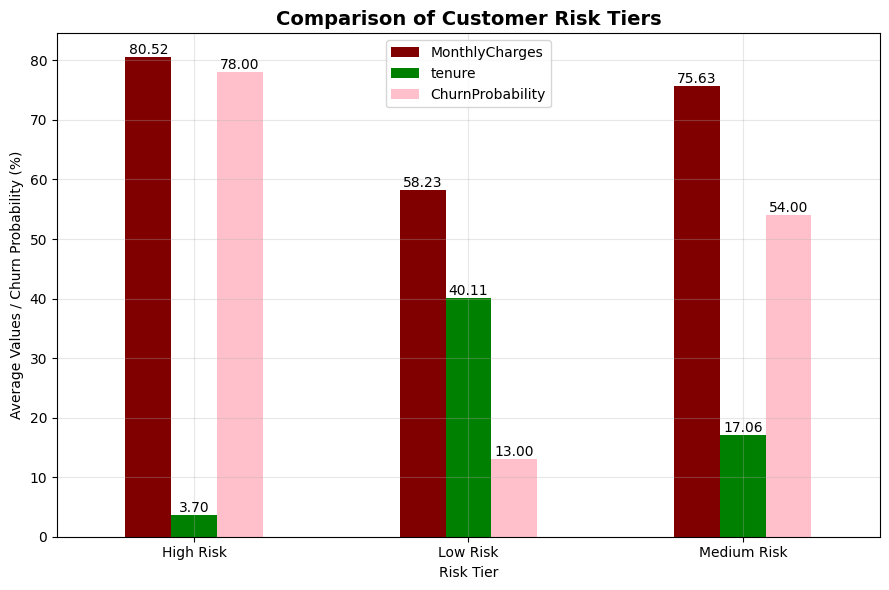

In [25]:
# Creating a copy of risk summary for visualization
risk_plot = risk_summary.copy()

# Converting churn probability into percentage format
risk_plot['ChurnProbability'] = risk_plot['ChurnProbability'] * 100

# Custom colors for bars
colors = ['maroon', 'green', 'pink']

# Creating grouped bar chart for risk tier comparison
risk_plot.plot(
    kind='bar',
    figsize=(9,6),
    color=colors
)

# Adding chart title and labels
plt.title(
    'Comparison of Customer Risk Tiers',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Risk Tier')
plt.ylabel('Average Values / Churn Probability (%)')

# Rotating x-axis labels
plt.xticks(rotation=0)

# Adding grid lines
plt.grid(alpha=0.3)

# Displaying values on bars
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.2f')

# Adjusting layout
plt.tight_layout()

# Saving chart
plt.savefig(
    'charts/risk_tier_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

# Displaying chart
plt.show()

In [26]:
# Analyzing contract types across different risk tiers
contract_analysis = risk_df.groupby('RiskTier')[
    ['Contract_One year', 'Contract_Two year']
].mean().round(2)

# Displaying contract distribution
contract_analysis

,Contract_One year,Contract_Two year
RiskTier,,
High Risk,0.00,0.00
Low Risk,0.29,0.34
Medium Risk,0.01,0.00


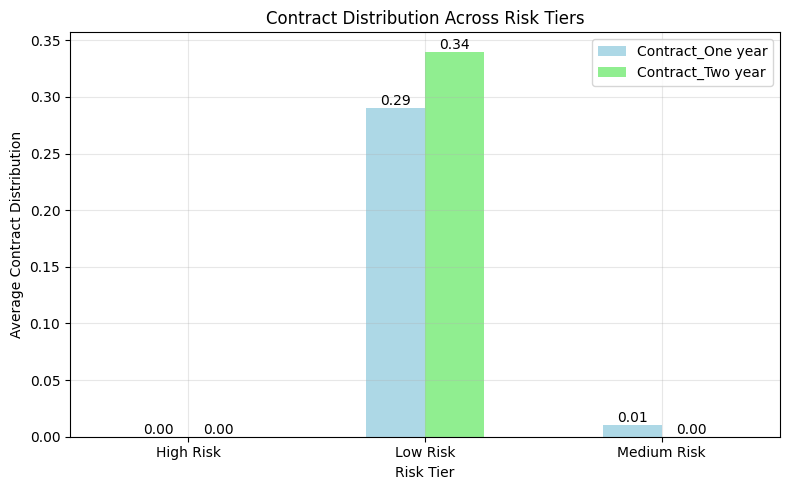

In [27]:
# Custom colors for bars
colors = ['lightblue', 'lightgreen',]

# Plotting contract distribution for different risk tiers
contract_analysis.plot(
    kind='bar',
    figsize=(8,5),
    color=colors
)

# Adding chart title and labels
plt.title('Contract Distribution Across Risk Tiers')
plt.xlabel('Risk Tier')
plt.ylabel('Average Contract Distribution')

# Keeping x-axis labels straight
plt.xticks(rotation=0)

# Adding grid lines
plt.grid(alpha=0.3)

# Displaying values on bars
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.2f')

# Adjusting layout
plt.tight_layout()

# Saving the chart
plt.savefig(
    'charts/contract_distribution_risk.png',
    dpi=300,
    bbox_inches='tight'
)

# Displaying the final chart
plt.show()

## TASK 5 — Visualizations

In this task, I created different visualizations to better understand customer churn behavior, feature importance, customer risk distribution, contract type patterns, and tenure trends. These visualizations helped in interpreting the machine learning results more effectively and generated meaningful business insights from the dataset.

In [28]:
# Creating Random Forest model with selected parameters
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

# Training the Random Forest model
rf_model.fit(X_train, y_train);

In [29]:
# Creating dataframe for feature importance values
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sorting features based on importance score
top_features = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

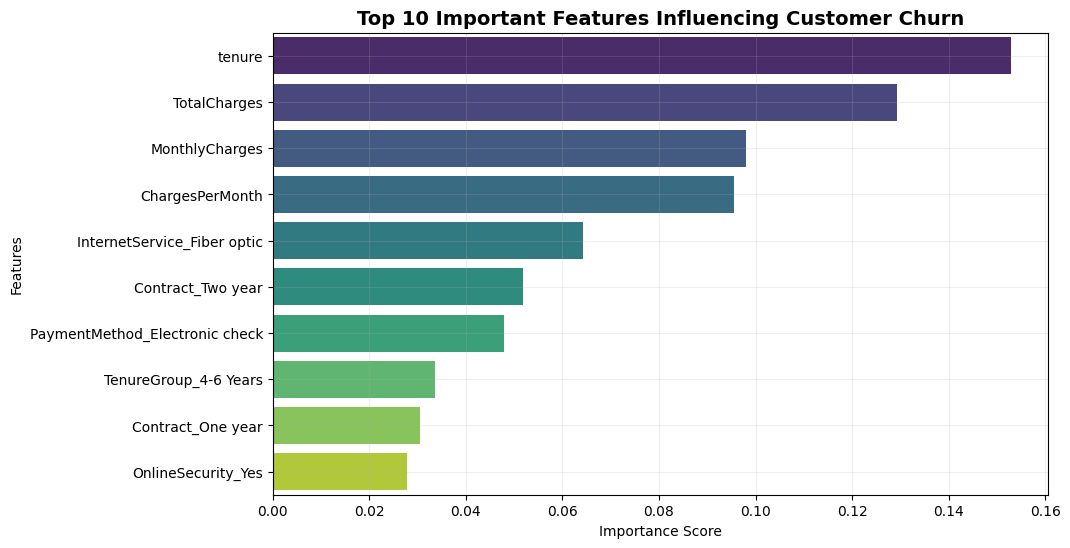

In [30]:
# Creating figure for feature importance visualization
plt.figure(figsize=(10, 6))

# Setting color palette
colors = sns.color_palette('viridis', 10)

# Plotting top important features
sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features,
    palette=colors
)

# Adding chart title
plt.title(
    'Top 10 Important Features Influencing Customer Churn',
    fontsize=14,
    fontweight='bold'
)

# Adding axis labels
plt.xlabel('Importance Score')
plt.ylabel('Features')

# Adding grid lines
plt.grid(alpha=0.2)

# Saving the chart
plt.savefig(
    'charts/feature_importance.png',
    dpi=300,
    bbox_inches='tight'
)

# Displaying final graph
plt.show()

In [31]:
# Creating a copy of risk dataframe for contract analysis
contract_df = risk_df.copy()

# Setting default contract type as Month-to-Month
contract_df['ContractType'] = 'Month-to-Month'

# Updating contract type for one year customers
contract_df.loc[
    contract_df['Contract_One year'] == 1,
    'ContractType'
] = 'One Year'

# Updating contract type for two year customers
contract_df.loc[
    contract_df['Contract_Two year'] == 1,
    'ContractType'
] = 'Two Year'

In [32]:
# Calculating average churn rate for each contract type
contract_churn = contract_df.groupby(
    'ContractType'
)['ActualChurn'].mean().reset_index()

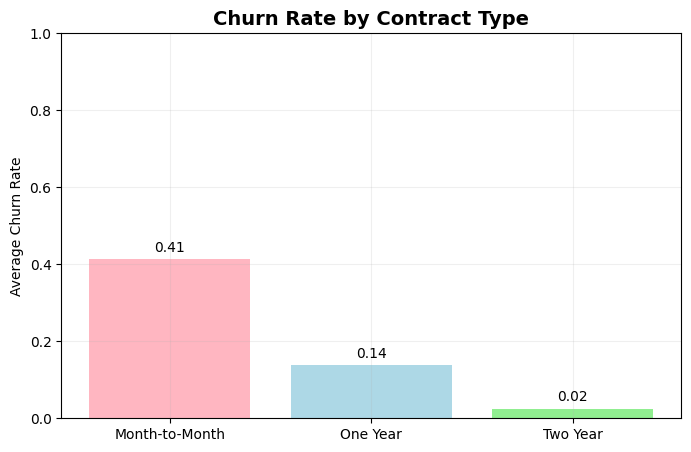

In [33]:
# Creating figure for churn rate comparison
plt.figure(figsize=(8, 5))

# Plotting churn rate by contract type
bars = plt.bar(
    contract_churn['ContractType'],
    contract_churn['ActualChurn'],
    color=['lightpink', 'lightblue', 'lightgreen']
)

# Adding chart title
plt.title(
    'Churn Rate by Contract Type',
    fontsize=14,
    fontweight='bold'
)

# Adding y-axis label
plt.ylabel('Average Churn Rate')

# Setting y-axis limit
plt.ylim(0, 1)

# Displaying values on bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f'{height:.2f}',
        ha='center'
    )

# Adding grid lines
plt.grid(alpha=0.2)

# Saving the chart
plt.savefig(
    'charts/churn_rate_contract_type.png',
    dpi=300,
    bbox_inches='tight'
)

# Displaying final graph
plt.show()

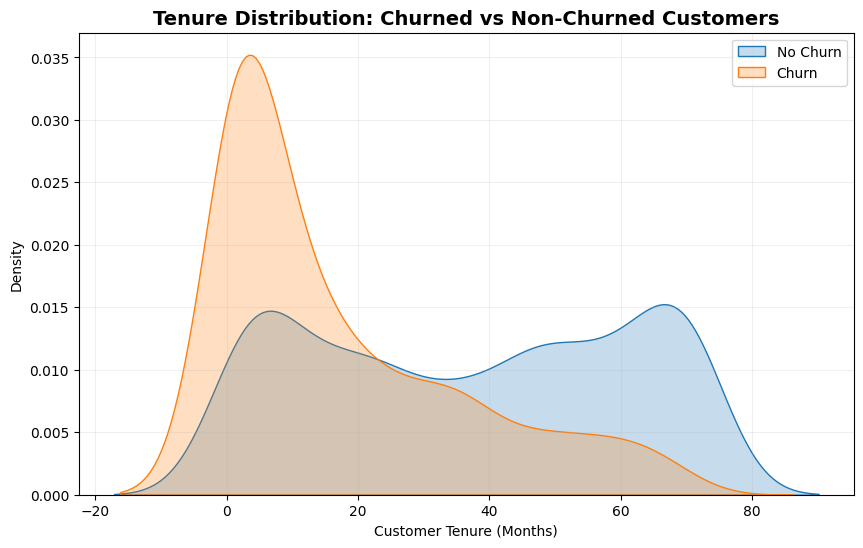

In [34]:
# Creating figure for tenure distribution analysis
plt.figure(figsize=(10, 6))

# Plotting tenure distribution for customers who did not churn
sns.kdeplot(
    data=risk_df[risk_df['ActualChurn'] == 0],
    x='tenure',
    fill=True,
    label='No Churn'
)

# Plotting tenure distribution for churned customers
sns.kdeplot(
    data=risk_df[risk_df['ActualChurn'] == 1],
    x='tenure',
    fill=True,
    label='Churn'
)

# Adding chart title
plt.title(
    'Tenure Distribution: Churned vs Non-Churned Customers',
    fontsize=14,
    fontweight='bold'
)

# Adding axis labels
plt.xlabel('Customer Tenure (Months)')
plt.ylabel('Density')

# Displaying legend
plt.legend()

# Adding grid lines
plt.grid(alpha=0.2)

# Saving the figure
plt.savefig(
    'charts/tenure_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

# Displaying final graph
plt.show()

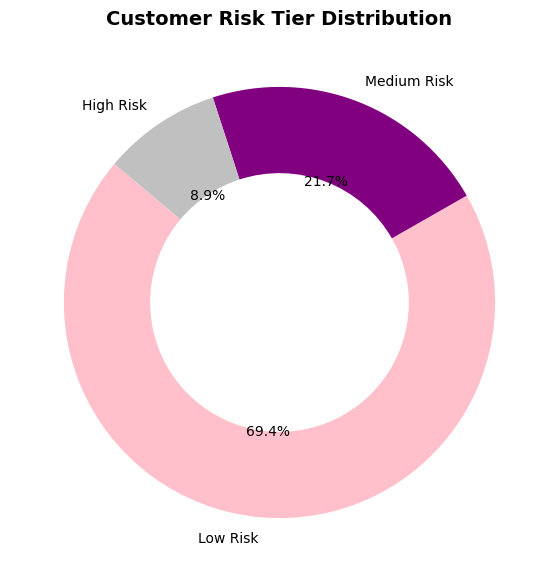

In [35]:
# Counting customers in each risk category
risk_counts = risk_df['RiskTier'].value_counts()

# Defining colors for pie chart
colors = ['Pink', 'Purple', 'Silver']

# Creating figure for risk tier distribution
plt.figure(figsize=(7, 7))

# Plotting donut chart
wedges, texts, autotexts = plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.4)
)

# Adding chart title
plt.title(
    'Customer Risk Tier Distribution',
    fontsize=14,
    fontweight='bold'
)

# Saving the chart
plt.savefig(
    'charts/risk_tier_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

# Displaying final char

ChurnLabel
No Churn    1033
Churn        374
Name: count, dtype: int64


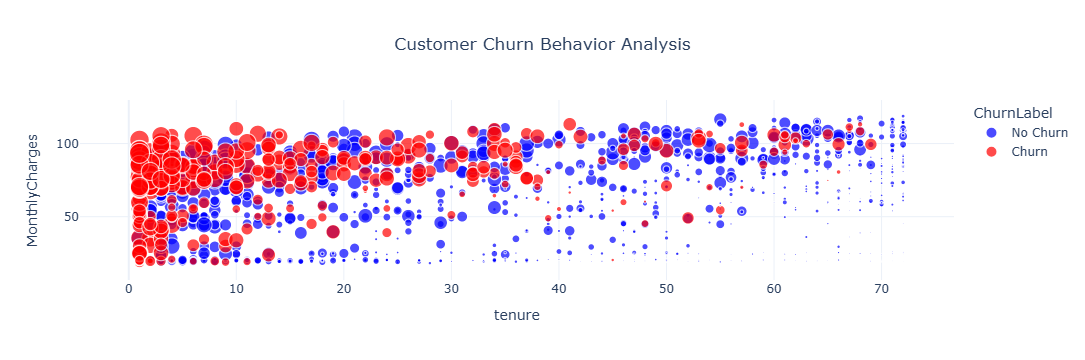

In [36]:
# Creating a copy of risk dataframe for plotting
plot_df = risk_df.copy()

# Converting churn values into integer format
plot_df['ActualChurn'] = plot_df['ActualChurn'].astype(int)

# Mapping churn values to readable labels
plot_df['ChurnLabel'] = plot_df['ActualChurn'].map({
    0: 'No Churn',
    1: 'Churn'
})

# Checking count of churn vs non-churn customers
print(plot_df['ChurnLabel'].value_counts())

# Creating interactive scatter plot for churn analysis
fig = px.scatter(
    plot_df,
    x='tenure',
    y='MonthlyCharges',
    color='ChurnLabel',
    size='ChurnProbability',
    hover_data=['RiskTier'],
    title='Customer Churn Behavior Analysis',
    color_discrete_sequence=['blue', 'red']
)

# Updating layout and styling
fig.update_layout(
    template='plotly_white',
    title_x=0.5,
    font=dict(size=12)
)

# Displaying the interactive plot
fig.show()

## TASK 6 — Insights & Business Recommendations

In this section, I summarized the overall findings from the customer churn prediction analysis. It includes model performance insights, important churn-driving factors, customer behavior analysis, business recommendations, project limitations, and the final conclusion based on the results obtained from the machine learning models.

### **1. Which model performed best and why did you select it?**

Ans - I performed total of 3 models which were Logistic Regression, Random Forest Classifier, and Gradient Boosting Classifier.

* After my analysis, I came to the conclusion that Logistic Regression to be the best overall. It achieved the highest ROC-AUC score of around 0.837, along with the balanced accuracy, recall, precision, and F1 score values. Though, the difference between all the models were not that large, but Logistic Regression gave most stable and consistent performance on the data I tested it with.

* I selected the Logistic Regression because it was simple, easier to interpret and still gave excellent predictions. Since this project is based on customer churn prediction, I feel understanding why are the customers leaving is as important as predicting the churn itself. I feel Logistic Regression makes it easier to understand how different features affect churn probability.

Another advantage was that the model trained quickly and was generalized well without showing any kind of signs of overfitting.

###  **2. What are the top 3 factors driving customer churn according to your model?**

Ans - According to my analysis and the results of feature importance, the top three factors that affect customer churn were Tenure, MonthlyCharges and Contract Type.

1. The most important factor I feel was Tenure. Customers with very low or short tenure were more likely to churn compared to customers who had stayed with the company for a long time. This analysis clearly depicts that new customers are less loyal and are more likely to leave the company during early months of their subscription. Whereas, on the other hand, long-term customers tend to build trust and familiarity with the company, which reduced the churn probability.

2. The second major factor I observed was MonthlyCharges. Customers paying higher monthly bills had a greater chance of churning because premium paying customers usually expect better service quality and hence, they become more sensitive to pricing or the offers their competitors are providing. If they feel the service is not worth the amount they are paying, they may switch to another provider.

3. The third important factor was Contract Type. Customers using month-to-month contracts had significantly higher churn rates compared to customers with one-year or two-year contracts. I feel long-term contracts create stronger customer commitment and reduce the chances of customers leaving frequently. This pattern was very clearly visible in the churn rate analysis by contract type.

Apart from these factors, features like internet service type, payment method, and online security services also contributed to churn prediction, but their impact was comparatively lower.

### **3. What do High Risk customers have in common? (contract type, charges, tenure patterns)**

Ans - During the analysis, the high-risk customer group showed some common patterns. Most high-risk customers had very low tenure, which means they were relatively new customers who had recently joined the service provided by the telecom. This tells us that first few months after customer acquisition are extremely important because customers are more likely to leave before building long-term loyalty.

* Another important pattern was related to MonthlyCharges. High-risk customers generally had higher monthly charges compared to low-risk customers. This indicates that customers paying expensive monthly fees may not always feel satisfied with the value they receive from the service. This tells us that they may also be more likely to switch to competitors offering cheaper or more attractive plans.

* Contract type also played a major role in customer churn. I observed that most high-risk customers had month-to-month contracts, while customers with yearly contracts showed much lower churn probability.

Overall, high-risk customers mostly had low tenure, high monthly charges, and flexible contract plans.


### **4. Write 2 specific, actionable business recommendations the company should implement**

Ans-
1. My first recommendation would be to focus strongly on retaining the customers during their first few months. Since my analysis showed that customers with low tenure have the highest churn probability, I feel the company should improve the onboarding experience of the new customers. If I think, it may include welcome offers, personalized support, follow-up intervals during regular times, and the company can also provide discounts during the early stages of the subscription.

2. During the analysis, I saw that customers with month-to-month contracts churn more frequently than customers who have annual contracts. So, my second recommendation would be to encourage more customers to move toward yearly or long-term contracts. To reduce churn, the company can provide incentives such as discounted yearly plans, loyalty rewards, or some added benefits for long-term users. This can help increase customer retention and improve long-term revenue stability.

### **5. What are the limitations of your model? What could be improved with more data or time?**

Ans -
1. One limitation I observed was that the dataset mainly contains customer demographic details, billing information, and subscription-         related features. However, it does not include factors like customer satisfaction, complaint history, network quality, competitor           pricing, or detailed customer behavior data. I feel these factors can play a major role in real-world customer churn.

2. Another limitation is that the dataset contains historical customer data from a fixed time period. Customer behavior and market             conditions keep changing over time, so the model may not always perform equally well in future situations unless it is updated and          retrained regularly with newer data.

3. The dataset also contains class imbalance because the number of non-churn customers is much higher than churn customers. Although           metrics like ROC-AUC helped evaluate the model properly, techniques like SMOTE, weighted models, or threshold tuning could further          improve prediction performance.

4. If more time and data were available, I feel this project could be improved using advanced machine learning models like XGBoost,            LightGBM, or CatBoost. Additional feature engineering based on customer interaction history and service usage patterns could also           improve prediction accuracy.

5. Moreover, I also feel this project can be converted into a live dashboard using Streamlit or Power BI for real-time churn monitoring and    better business decision-making.

### Final Conclusion

In this project, I successfully built a machine learning-based customer churn prediction and risk segmentation system using telecom customer data. During the analysis, I found that customers with low tenure, high monthly charges, and month-to-month contracts had a higher probability of churn. Among all the trained models, Logistic Regression performed the best overall by giving a good balance between prediction performance, stability, and interpretability. 

I also performed customer risk segmentation to classify customers into High Risk, Medium Risk, and Low Risk categories based on churn probability. This analysis can help businesses identify risky customers earlier and take better customer retention actions. Overall, this project helped me understand the complete machine learning workflow including data preprocessing, model training, evaluation, visualization, and business insight generation.
